# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

os.makedirs("images", exist_ok=True)

# Load Dataset

In [2]:
df = pd.read_csv("data/telco_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Information

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Churn Distribution

The distribution shows how many customers have churned versus those who remain active.

Understanding the overall churn rate provides a baseline for further analysis of customer behavior.

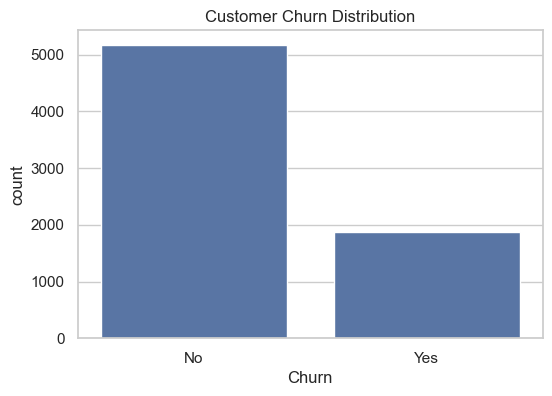

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")

plt.savefig("images/churn_distribution.png", dpi=300)

plt.show()

## Churn by Contract Type

Customers with month-to-month contracts show significantly higher churn rates compared with customers on longer-term contracts.

This suggests that contract duration plays an important role in customer retention.

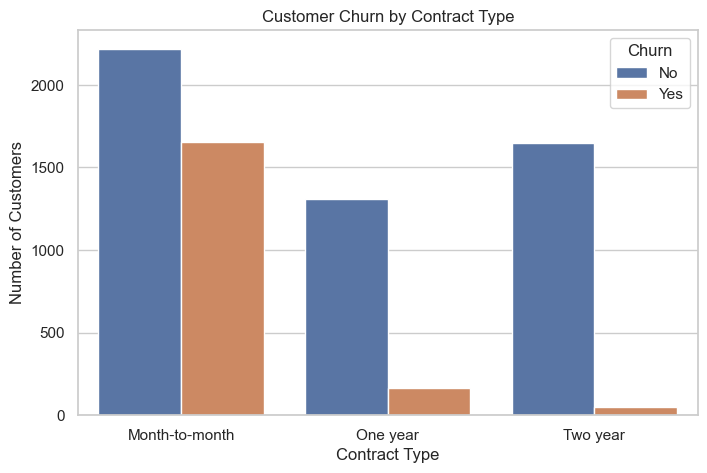

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.savefig("images/churn_by_contract.png", dpi=300)

plt.show()

## Churn by Customer Tenure

Customers with shorter tenure are more likely to churn compared to long-term customers.

This indicates that the first months of the customer lifecycle are critical for retention.

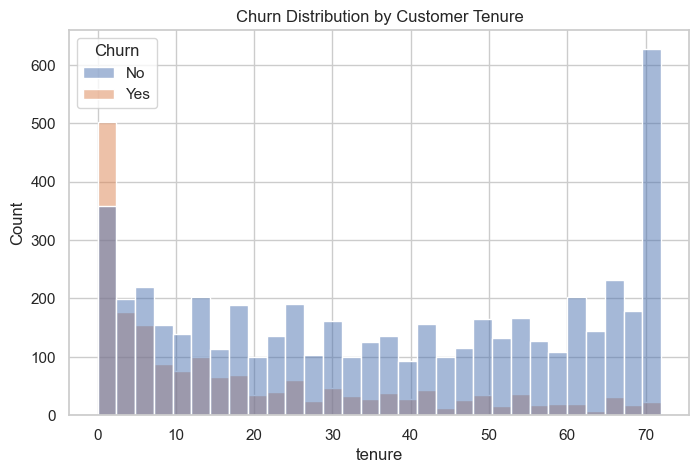

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30)

plt.title("Churn Distribution by Customer Tenure")

plt.savefig("images/churn_by_tenure.png", dpi=300)

plt.show()

## Monthly Charges vs Churn

Customers who churn tend to have slightly higher monthly charges.

This may suggest that pricing plays a role in customer dissatisfaction.

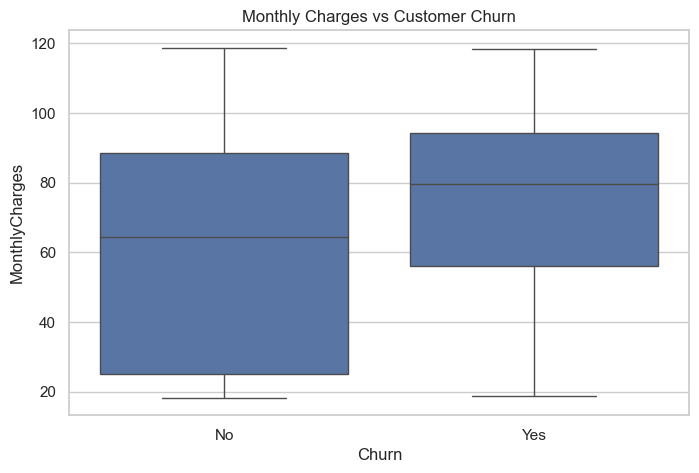

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")

plt.savefig("images/churn_by_charges.png", dpi=300)

plt.show()

## Churn by Internet Service Type

Different internet service types show different churn patterns.

Understanding these differences may help identify service-related issues affecting customer retention.

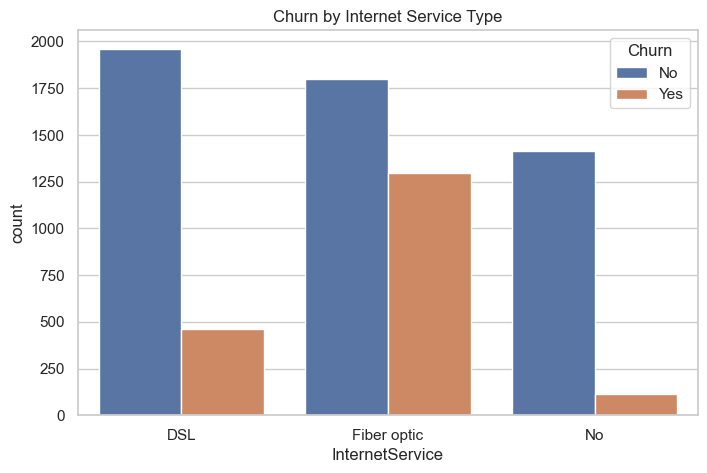

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Churn by Internet Service Type")

plt.savefig("images/churn_by_internet_service.png", dpi=300)

plt.show()

## Churn by Payment Method

Certain payment methods appear to have higher churn rates.

This could reflect differences in customer convenience or billing experience.

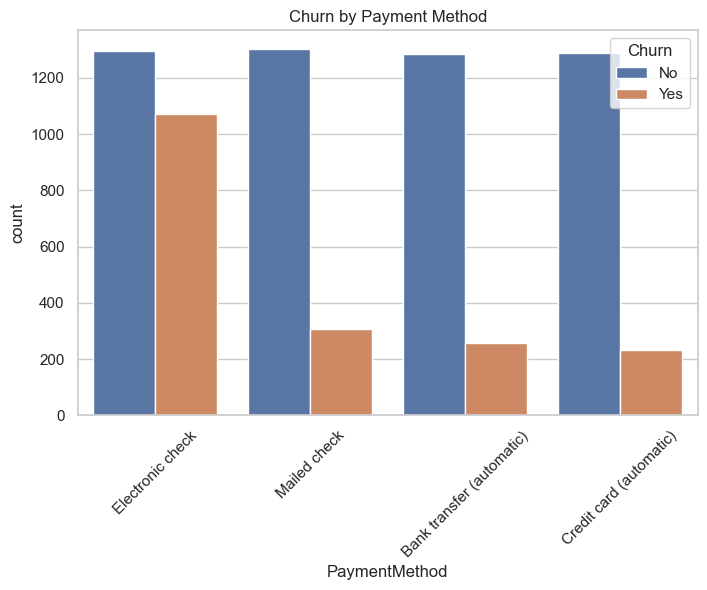

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.xticks(rotation=45)

plt.title("Churn by Payment Method")

plt.savefig("images/churn_by_payment_method.png", dpi=300)

plt.show()

## High-Risk Customer Segments

The analysis suggests that customers with the following characteristics are more likely to churn:

• Month-to-month contracts
• Short tenure
• Higher monthly charges

## High-Risk Customer Segments

The analysis suggests that customers with the following characteristics are more likely to churn:

• Month-to-month contracts
• Short tenure
• Higher monthly charges## Key Insights

Based on the exploratory analysis of the customer churn dataset, several important patterns emerge:

• **Contract type is strongly related to churn**
Customers with month-to-month contracts have significantly higher churn rates compared with customers who have one-year or two-year contracts.

• **Customer tenure plays a major role in retention**
Customers with shorter tenure are more likely to churn. This suggests that the early stage of the customer lifecycle is a critical period for retention.

• **Higher monthly charges are associated with higher churn probability**
Customers paying higher monthly fees appear more likely to leave the service.

• **Service and payment characteristics influence churn behavior**
Different internet service types and payment methods show different churn patterns, indicating that service experience and billing convenience may affect customer satisfaction.

These insights help identify customer segments with higher churn risk.

## Business Recommendations

Based on the analysis, several strategies could help reduce customer churn:

• **Encourage longer-term contracts**
Offering incentives for customers to switch from month-to-month contracts to annual plans may significantly improve retention.

• **Focus on early customer engagement**
Since churn is higher among new customers, companies should invest in onboarding programs, early customer support, and loyalty incentives.

• **Review pricing strategy**
Customers with higher monthly charges are more likely to churn, suggesting that pricing and perceived value should be carefully evaluated.

• **Improve service experience**
Differences in churn across internet services indicate that service quality and reliability may impact retention.

• **Target high-risk segments with retention campaigns**
Customer segments identified as high churn risk could be targeted with personalized offers or retention strategies.